<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Finding Outliers**


Estimated time needed: **30** minutes


In this lab, you will work with a cleaned dataset to perform exploratory data analysis or EDA. 
You will explore the distribution of key variables and focus on identifying outliers in this lab.


## Objectives


In this lab, you will perform the following:


-  Analyze the distribution of key variables in the dataset.

-  Identify and remove outliers using statistical methods.

-  Perform relevant statistical and correlation analysis.


#### Install and import the required libraries


In [1]:
!pip install pandas
!pip install matplotlib
!pip install seaborn

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 179.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 197.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 137.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 135.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 84.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 153.1 MB/s eta 0:00:00


<h3>Step 1: Load and Explore the Dataset</h3>


Load the dataset into a DataFrame and examine the structure of the data.


In [19]:
file_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"

#Create the dataframe
df = pd.read_csv(file_url)

#Display the top 10 records
df.head()


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


<h3>Step 2: Plot the Distribution of Industry</h3>


Explore how respondents are distributed across different industries.

- Plot a bar chart to visualize the distribution of respondents by industry.

- Highlight any notable trends.


In [20]:
##Write your code here
df = df.copy()
mode = df['Industry'].mode()[0]
df['Industry'] = df['Industry'].fillna(mode)
df['Industry'].isna().sum()

np.int64(0)

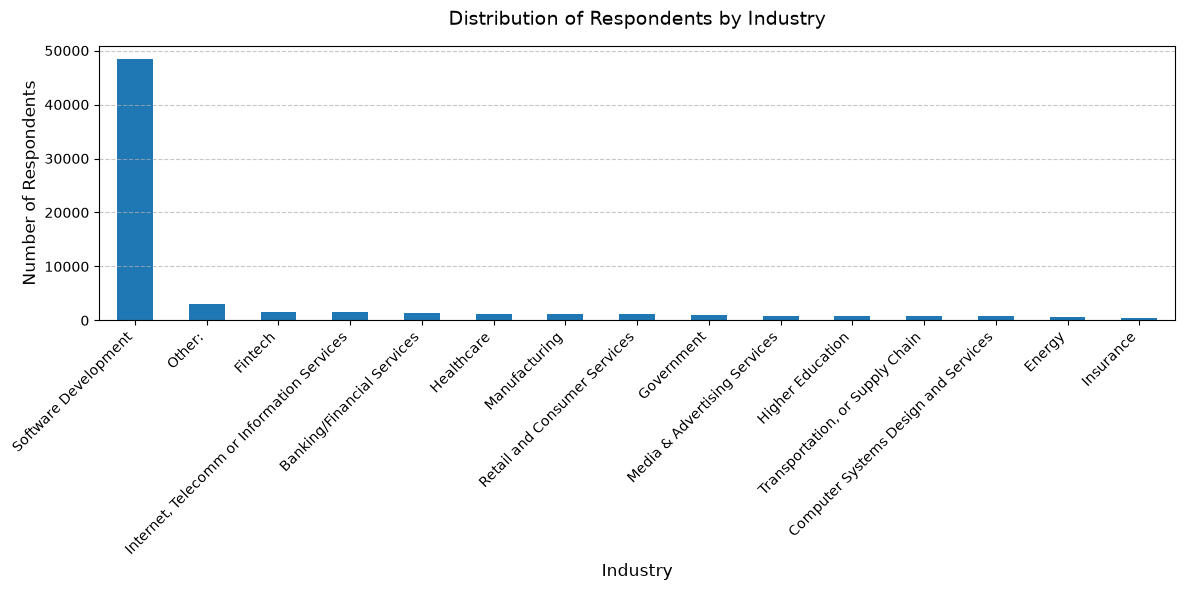

In [21]:
ind = df['Industry'].value_counts()
plt.figure(figsize = (12, 6))
ind.plot(kind='bar')
plt.title("Distribution of Respondents by Industry", fontsize=14, pad=15)
plt.xlabel("Industry", fontsize=12)
plt.ylabel("Number of Respondents", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()

<h3>Step 3: Identify High Compensation Outliers</h3>


Identify respondents with extremely high yearly compensation.

- Calculate basic statistics (mean, median, and standard deviation) for `ConvertedCompYearly`.

- Identify compensation values exceeding a defined threshold (e.g., 3 standard deviations above the mean).


In [32]:
##Write your code here
df = df.copy()
median_con = df['ConvertedCompYearly'].median()
df['ConvertedCompYearly'] = df['ConvertedCompYearly'].fillna(median_con)
mean_val = df["ConvertedCompYearly"].mean()
median_val = df["ConvertedCompYearly"].median()
std_val = df["ConvertedCompYearly"].std()

print(f"Mean Compensation: {int(mean_val):,}")
print(f"Median Compensation: {int(median_val):,}")
print(f"Standard Deviation: {int(std_val):,}")

threshold = mean_val + (3 * std_val)
print(f"\nOutlier Threshold (Mean + 3*STD): {int(threshold):,}")

high_earners_df = df[df["ConvertedCompYearly"] > threshold]

print(f"Number of extreme outliers found: {len(high_earners_df)}")

Mean Compensation: 72,576
Median Compensation: 65,000
Standard Deviation: 112,220

Outlier Threshold (Mean + 3*STD): 409,238
Number of extreme outliers found: 194


<h3>Step 4: Detect Outliers in Compensation</h3>


Identify outliers in the `ConvertedCompYearly` column using the IQR method.

- Calculate the Interquartile Range (IQR).

- Determine the upper and lower bounds for outliers.

- Count and visualize outliers using a box plot.


Lower Bound for Outliers: 65,000
Upper Bound for Outliers: 65,000
Low outliers found: 11691
High outliers found: 11707
Total outliers found: 23398


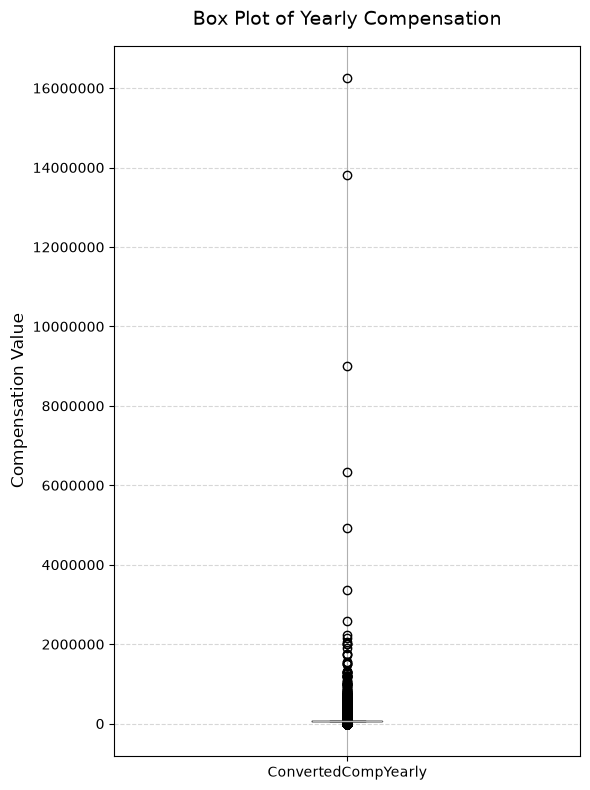

In [37]:
##Write your code here
df = df.copy()
q1 = df['ConvertedCompYearly'].quantile(0.25)
q3 = df['ConvertedCompYearly'].quantile(0.75)
IQR = q3 - q1
lower_bound = q1 - (1.5 * IQR) #The number 1.5 is a statistical standard
upper_bound = q3 + (1.5 * IQR)

print(f"Lower Bound for Outliers: {int(lower_bound):,}")
print(f"Upper Bound for Outliers: {int(upper_bound):,}")

#Identify and count outliers
outliers_lower = df[df["ConvertedCompYearly"] < lower_bound]
outliers_upper = df[df["ConvertedCompYearly"] > upper_bound]
total_outliers = len(outliers_lower) + len(outliers_upper)

print(f"Low outliers found: {len(outliers_lower)}")
print(f"High outliers found: {len(outliers_upper)}")
print(f"Total outliers found: {total_outliers}")

plt.figure(figsize=(6, 8))
df.boxplot(column=["ConvertedCompYearly"])

plt.title("Box Plot of Yearly Compensation", fontsize=14, pad=15)
plt.ylabel("Compensation Value", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.5)

#Fix scientific notation on y-axis if numbers are huge
plt.ticklabel_format(style="plain", axis="y")

plt.tight_layout()
plt.show()

<h3>Step 5: Remove Outliers and Create a New DataFrame</h3>


Remove outliers from the dataset.

- Create a new DataFrame excluding rows with outliers in `ConvertedCompYearly`.
- Validate the size of the new DataFrame.


In [43]:
##Write your code here
df_working = df.dropna(subset=["ConvertedCompYearly"]).copy()

q1 = df_working["ConvertedCompYearly"].quantile(0.25)
q3 = df_working["ConvertedCompYearly"].quantile(0.75)
IQR = q3 - q1

lower_bound = q1 - (1.5 * IQR)
upper_bound = q3 + (1.5 * IQR)

#Create a new DataFrame excluding the outliers
df_cleaned = df_working[
    (df_working["ConvertedCompYearly"] >= lower_bound)
    & (df_working["ConvertedCompYearly"] <= upper_bound)
].copy()

#Validate the sizes of the DataFrames
original_total = len(df)
dropped_na_total = len(df_working)
cleaned_total = len(df_cleaned)
outliers_removed = dropped_na_total - cleaned_total

print("DATA VALIDATION REPORT")
print("=" * 30)
print(f"Original Rows (with NaNs):     {original_total:,}")
print(f"Rows after dropping NaNs:      {dropped_na_total:,}")
print(f"Cleaned Rows (No Outliers):    {cleaned_total:,}")
print("-" * 30)
print(f"Total Outlier Rows Removed:    {outliers_removed:,}")

DATA VALIDATION REPORT
Original Rows (with NaNs):     65,437
Rows after dropping NaNs:      65,437
Cleaned Rows (No Outliers):    42,039
------------------------------
Total Outlier Rows Removed:    23,398


<h3>Step 6: Correlation Analysis</h3>


Analyze the correlation between `Age` (transformed) and other numerical columns.

- Map the `Age` column to approximate numeric values.

- Compute correlations between `Age` and other numeric variables.

- Visualize the correlation matrix.


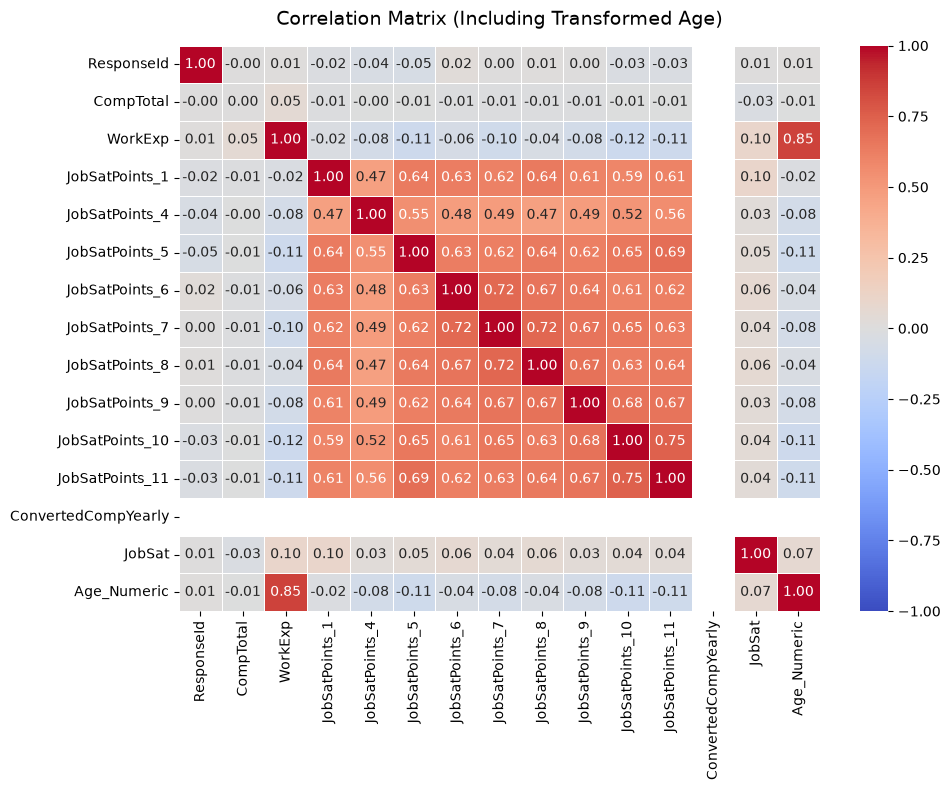

In [44]:
##Write your code here
df_analysis = df_cleaned.copy()

age_mapping = {
    "Under 18 years old": 16,
    "18-24 years old": 21,
    "25-34 years old": 29,
    "35-44 years old": 39,
    "45-54 years old": 49,
    "55-64 years old": 59,
    "65 years or older": 68,
}

# Apply the transformation to a new column
df_analysis["Age_Numeric"] = df_analysis["Age"].map(age_mapping)

#Isolate the numerical columns for correlation analysis
numerical_df = df_analysis.select_dtypes(include=["number"])

#Compute the correlation matrix
correlation_matrix = numerical_df.corr()

plt.figure(figsize=(10, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,  # Displays the correlation numbers inside the boxes
    cmap="coolwarm",  # Red for positive correlation, Blue for negative
    fmt=".2f",  # Limits decimal points to 2 digits
    linewidths=0.5,  # Adds a clean white border between squares
    vmin=-1,  # Sets the minimum scale bound
    vmax=1,  # Sets the maximum scale bound
)

plt.title("Correlation Matrix (Including Transformed Age)", fontsize=14, pad=15)
plt.tight_layout()
plt.show()

<h3> Summary </h3>


In this lab, you developed essential skills in **Exploratory Data Analysis (EDA)** with a focus on outlier detection and removal. Specifically, you:


- Loaded and explored the dataset to understand its structure.

- Analyzed the distribution of respondents across industries.

- Identified and removed high compensation outliers using statistical thresholds and the Interquartile Range (IQR) method.

- Performed correlation analysis, including transforming the `Age` column into numeric values for better analysis.


<!--
## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|               
|2024-10-1|1.1|Madhusudan Moole|Reviewed and updated lab|                                                                                    
|2024-09-29|1.0|Raghul Ramesh|Created lab|
--!>


Copyright © IBM Corporation. All rights reserved.
